In [1]:
import sys
import os
# Get the absolute path to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# Add it to sys.path
sys.path.append(project_root)
os.chdir(project_root)

In [2]:
import numpy as np
from bimpcc.dataset import get_dataset
from bimpcc.models.tvqregularized_sinbeta_sparse import TVqRegularized
from bimpcc.models.tvq_denoising_sinbeta import TVDenoisingMPCC
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from bimpcc.utils import generate_2D_gradient_matrices

In [3]:
def plot_experiment(true,noisy,u, alpha):
    
    fig,ax = plt.subplots(1,3,figsize=(14,4))
    ax[0].imshow(true,cmap='gray')
    ax[0].set_title('True Image')
    ax[0].axis('off')
    ax[1].imshow(noisy,cmap='gray')
    ax[1].set_title(f'Noisy Image\nPSNR: {psnr(noisy,true):.4f}\n SSIM={ssim(noisy,true, data_range=1.0):.4f}')
    ax[1].axis('off')
    ax[2].imshow(u,cmap='gray')
    ax[2].set_title(f'Reconstructed Image\nPSNR: {psnr(true,u):.4f}\n SSIM={ssim(noisy,true, data_range=1.0):.4f}\n alpha = {alpha}')
    # ax[2].set_xlabel('alpha = {}'.format(alpha))
    ax[2].axis('off')

    plt.show()
    
    return psnr(true,noisy), psnr(true,u)

In [4]:
scale = 32

In [5]:
name_exp = "square"
dataset = get_dataset(name_exp,scale=scale, random_state=1)
true, noisy = dataset.get_training_data()

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

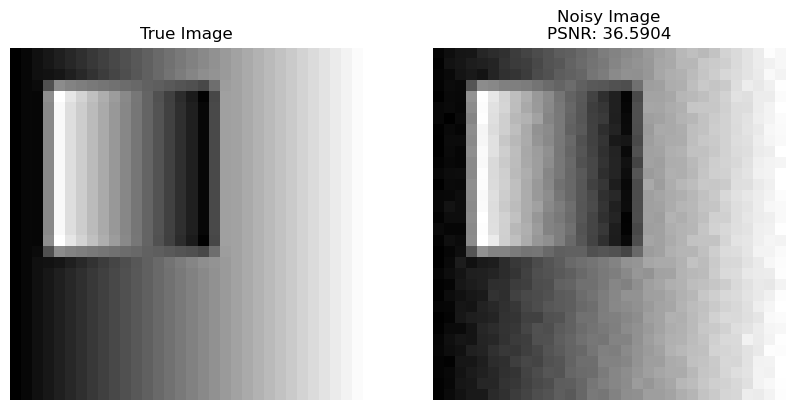

In [6]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(true,cmap='gray')
ax[0].set_title('True Image')
ax[0].axis('off')
ax[1].imshow(noisy,cmap='gray')
ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
ax[1].axis('off')

In [7]:
q_param = 0.7
model = TVqRegularized(true, noisy, epsilon=1e-1, q_param=q_param)

In [8]:
res,x_opt,fun_opt = model.solve(max_iter=3000,tol=1e-4,print_level=5)

[100.]
[100.]
[100.]
[99.9898612]
[104.45539814]
[107.66013673]
[106.3713084]
[87.87892]
[87.84659594]
[87.86993214]
[87.87823978]
[87.91363835]
[88.52703152]
[89.14559489]
[88.98937776]
[89.39909188]
[89.20421026]
[89.62845446]
[89.40157562]
[89.75089039]
[89.54224302]
[89.54291556]
[89.68482478]
[89.55875784]
[89.4585193]
[89.55875784]
[89.55994243]
[89.55934549]
[90.709738]
[107.59137356]
[97.60995597]
[200.16490255]
[216.73081196]
[175.58191311]
[201.79504272]
[149.61533007]
[171.39528814]
[185.2414312]
[192.11842657]
[208.26728877]
[176.75542544]
[191.01510417]
[205.14153692]
[186.5075669]
[193.03735623]
[193.56829864]
[192.09722562]
[191.55381701]
[191.6432096]
[191.91082119]
[191.75019923]
[191.77913454]
[191.8160409]
[191.77554859]
[191.7686704]
[191.83539228]
[191.78875317]
[191.7630563]
[191.78941916]
[191.79490068]
[191.78723441]
[191.78320569]
[191.7867423]
[191.80318743]
[191.78680209]
[191.78316506]
[191.78735322]


In [9]:
print(open("ipopt.log", "r", encoding="utf-8", errors="ignore").read()[:5000])


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.1.

Number of nonzeros in equality constraint Jacobian...:    49148
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     3009
                     variables with only lower bounds:     1025
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:     3008
Total number of inequality c

In [10]:
u, q, alpha = model.objective_func.parse_vars(x_opt)

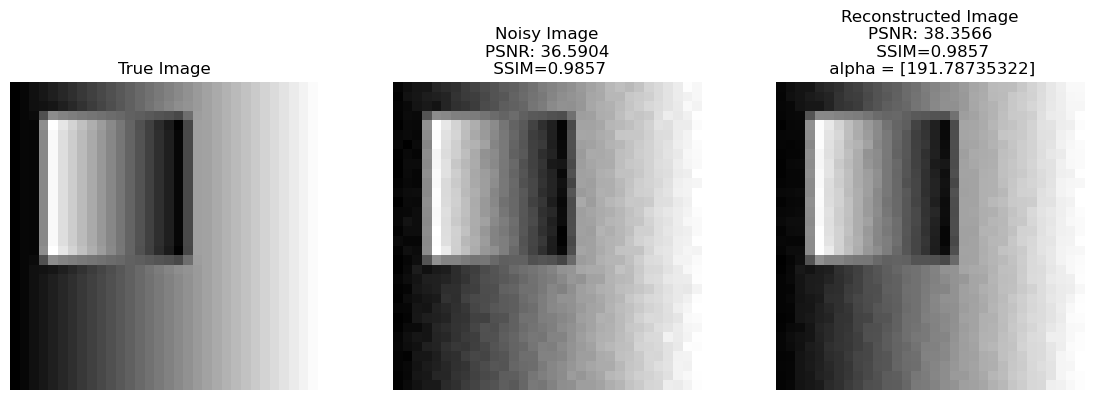

In [11]:
u_scaled = u.reshape((scale,scale))
psnr_n, psnr_r = plot_experiment(true,noisy,u_scaled,alpha)

In [ ]:
# from pathlib import Path
# from imageio import imwrite

In [19]:

out_dir = Path("results_tvq") / "guacamayo"   # <- dos carpetas
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"true_{name_exp}_{scale}.png"
imwrite(str(out_path), (true * 255).astype(np.uint8))

In [ ]:
out_path = out_dir / f"noisy_{name_exp}_{scale}_{psnr_n:.4f}.png"
imwrite(str(out_path), (noisy * 255).astype(np.uint8))

In [ ]:
out_path = out_dir / f"recons_{name_exp}_{scale}_{psnr_r:.4f}_{alpha[0]:.2f}.png"
imwrite(str(out_path), (u_scaled * 255).astype(np.uint8))